In [1]:
%matplotlib inline

import sys
sys.path.append('lib/')
import matplotlib.pyplot as plt 
from likelihood_sbratio_2d import Likelihood
import numpy as np
import pandas as pd
import pickle
import itertools
from scipy.integrate import quad
from scipy.stats import chi2
from matplotlib.lines import Line2D

from palettable.cubehelix import Cubehelix
cx = Cubehelix.make(start=0.3, rotation=-0.5, n=16, reverse=True, gamma=1.0,
                     max_light=1.0, max_sat=0.5, min_sat=1.4).get_mpl_colormap()
from matplotlib.colors import LinearSegmentedColormap
llh_map = LinearSegmentedColormap.from_list("NewPSMap",["#3972A0", "w"], gamma=0.7)

def figsize(scale, ratio=(np.sqrt(5.0)-1.0)/2.0):
    fig_width_pt = 455.8843                         
    inches_per_pt = 1.0/72.27                      
    fig_width = fig_width_pt*inches_per_pt*scale   
    fig_height = fig_width*ratio            
    fig_size = [fig_width,fig_height]
    return fig_size

In [2]:
# Read the effective area spline and define the conversion between 
# number of signal events and flux normalization

with open('./lib/aeff_spline.pkl', 'rb') as ifile:
    aeff_spline = pickle.load(ifile)
    
def phi0_to_mu(phi0, gamma):
    seconds = 3186.105475562 * 24 * 60 * 60
    mu= quad(lambda x: aeff_spline(x) * phi0 * (x/1000)**(-gamma),
             1e2, 1e7, epsabs=1.49e-12, epsrel=1.49e-12, limit=200,)[0]
    return mu * seconds

def mu_to_phi0(mu, gamma):
    seconds = 3186.105475562 * 24 * 60 * 60
    phi0= mu/quad(lambda x: aeff_spline(x)* (x/1000)**(-gamma),
                   1e2, 1e7, epsabs=1.49e-12, epsrel=1.49e-12, limit=200,)[0]
    return phi0/seconds

In [3]:
# from Fermi 4FGL

src_ra = 40.667
src_dec = -0.0069

# Fitting NGC 1068

In [4]:
# Initialize the analysis class and load the data 

stats = Likelihood(src_ra, src_dec)
idata = pd.read_csv('../resources/event_list.txt')
stats.set_data(idata)

In [5]:
#Perform fit at the location of NGC 1068 and print the results

result, ts = stats.fit()

ns, gamma = result[0], result[1]
phi0 = mu_to_phi0(ns, gamma)
print('ns: {:.3f}, phi0: {}, gamma: {:.3f}, TS: {:.3f}'.format(ns, phi0,
                                                               gamma, ts))

ns: 78.787, phi0: 4.9032578920279493e-14, gamma: 3.196, TS: 29.234


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/ipykernel_launcher.py:16: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  app.launch_new_instance()


# TS Map

In [6]:
# Initialize the analysis class and load the data 

stats = Likelihood(src_ra, src_dec)
idata = pd.read_csv('../resources/event_list.txt')
stats.set_data(idata)

In [12]:
# Make the finescan of the region around NGC 1068 (Fig. 2a of the paper).
# The resolution is controled through the 'resolution' parameter.

# The plot in the paper uses a resolution of 300, which is computaionally heavy. 
# If you only need the result check the the 'resources' folder.
# Using a smaller resolution will result in less accuracy due to binning effects

resolution = 30
delta = 1.0
edges_x = np.linspace(src_ra-delta,
                      src_ra+delta,
                      resolution+1)
edges_y = np.linspace(src_dec-delta,
                      src_dec+delta,
                      resolution+1)
centers_x = 0.5 * (edges_x[1:]+edges_x[:-1])
centers_y = 0.5 * (edges_y[1:]+edges_y[:-1])
hist_ts = np.zeros(shape=(len(centers_x),
                   len(centers_y)))
for i, ra in enumerate(centers_x):
    for j, dec in enumerate(centers_y):
        if (((i * resolution + j + 1)/ (resolution **2)) * 100) % 5 == 0:
            print('{} %'.format(( i * resolution + j + 1)/ (resolution **2) * 100))
        stats.set_src_pos(src_ra=ra,
                          src_dec=dec)
        result, TS = stats.fit()
        hist_ts[i, j] = TS

5.0 %
10.0 %
15.0 %
20.0 %
25.0 %
30.0 %
35.0 %
40.0 %
45.0 %
50.0 %
60.0 %
65.0 %
70.0 %
75.0 %
80.0 %
85.0 %
90.0 %
95.0 %
100.0 %


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/ipykernel_launcher.py:8: UserWarning: The following kwargs were not used by contour: 'bins'
  
/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/ipykernel_launcher.py:50: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.


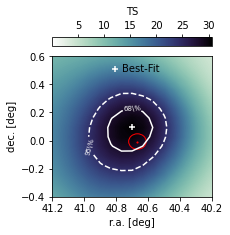

In [13]:
#Plot the finescan

fig = plt.figure(figsize=figsize(0.45, 0.8))
ax = fig.add_axes((.0, .0, 0.78, .86))
X, Y = np.meshgrid(centers_x, centers_y)

cbar = ax.contourf(X, Y, hist_ts.T, bins=[edges_x, edges_y], # -np.log10(hist_ts.T)
                   cmap=cx, levels=500)
CS = ax.contour(X, Y, -(hist_ts.T - np.max(hist_ts.T)),
                levels=[2.61439763, 6.64916465],
                colors=['w', 'w'], linestyles=['-', '--'], zorder=5)
plt.clabel(CS, fmt={2.61439763: r'68\%',
                    6.64916465: r'95\%'},
           inline=1, fontsize=7, inline_spacing=-4)
# max_ind = np.where(hist_p.T == np.min(hist_p.T))
max_ind= np.where(hist_ts.T == np.max(hist_ts.T))

ax.scatter(X[max_ind], Y[max_ind],
           marker="+", s=30, color='w', label='Best-Fit')
x, y, r = src_ra, src_dec, 0.055
ax.scatter(x, y, marker=".", s=5, color='red')
circle = plt.Circle((x,y), r, color='red',
                    linewidth=1, fill=False)
ax.add_artist(circle)
red_circle = Line2D([x], [y], marker=r'$\odot$', color='r',
                    markersize=7, ls='')
handles, labels = ax.get_legend_handles_labels()
handles.append(red_circle)
labels.append('NGC 1068')
# ax.scatter(src_ra, src_dec, s=55, edgecolor='#c4bc73', linewidth=0.35,
#            marker='*', color='red', label='NGC 1068',
#            zorder=20)

ax.set_ylim(-0.4, 0.6)
ax.set_xlim(40.2, 41.2)
ax.set_xticks(np.linspace(40.2, 41.2, 6))
ax.set_xlabel(r'r.a. [deg]')
ax.set_ylabel(r'dec. [deg]')

ax2 = fig.add_axes((.0, .92, 0.78, 0.055))
plt_cbar = fig.colorbar(cbar, orientation="horizontal", cax=ax2)
plt_cbar.ax.xaxis.set_ticks_position('top')
plt_cbar.ax.xaxis.set_label_position('top')
plt_cbar.set_ticks([5, 10, 15, 20, 25, 30])
plt_cbar.ax.xaxis.set_tick_params(pad=3)
plt_cbar.set_label(r"TS", labelpad=6)
ax.invert_xaxis()
legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.01),
                   frameon=False, handletextpad=-0.3, ncol=2)
fig.show()

# Flux Scan

In [9]:
# Initialize the analysis class and load the data 

stats = Likelihood(src_ra, src_dec)
idata = pd.read_csv('../resources/event_list.txt')
stats.set_data(idata)

In [10]:
# Make a scan in flux normalization and spectral index (Fig. 3 of the paper)
# The resolution is controled through the 'resolution' parameter

# The plot in the paper uses a resolution of 300, which is computaionally heavy. 
# If you only need the result check the the 'resources' folder.
# Using a smaller resolution will result in less accuracy due to binning effects

resolution = 40 
ret_dict = dict()
phi0_grid =10**np.linspace(-15.0, -12.5, resolution)
gamma_grid = np.linspace(2.3, 4.0, resolution)
X, Y = np.meshgrid(gamma_grid, phi0_grid)
res_grid2 = np.zeros(shape=np.shape(X))
tper = int(resolution * resolution / 10.)
for c, i in enumerate(itertools.product(range(resolution), range(resolution))):
    if (c % tper == 0) & (c>0):
        print('{} %'.format(100. * c /( resolution * resolution)))
    tmu = phi0_to_mu(Y[i[0]][i[1]], X[i[0]][i[1]])
    res_grid2[i[0]][i[1]] = 2 * stats.logl(tmu, X[i[0]][i[1]])

result, ts = stats.fit()
ns, gamma = result[0], result[1]
phi0 = mu_to_phi0(ns, gamma)    

ret_dict_2d = dict()
ret_dict_2d['phi0'] = Y
ret_dict_2d['gamma'] = X
ret_dict_2d['ts'] = res_grid2
ret_dict_2d['bf'] = [phi0, gamma, ts]
ret_dict['2D_phi0'] = ret_dict_2d

ret_dict_1d_gamma = dict()
ret_dict_1d_gamma['gamma'] = gamma_grid
ret_dict_1d_gamma['ts'] = np.max(res_grid2, axis=0)
ret_dict['1D_gamma'] = ret_dict_1d_gamma

ret_dict_1d_phi0 = dict()
ret_dict_1d_phi0['phi0'] = phi0_grid
ret_dict_1d_phi0['ts'] = np.max(res_grid2, axis=1)
ret_dict['1D_phi0'] = ret_dict_1d_phi0

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/ipykernel_launcher.py:10: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  # Remove the CWD from sys.path while we load stuff.


10.0 %
20.0 %
30.0 %
40.0 %
50.0 %
60.0 %
70.0 %
80.0 %
90.0 %


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/ipykernel_launcher.py:16: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  app.launch_new_instance()


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/ipykernel_launcher.py:79: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.


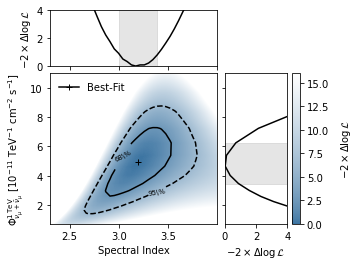

In [11]:
#Plot the scan result in flux normalization and spectral index

idata_new = ret_dict
fig = plt.figure(figsize=figsize(0.55, ratio=0.9))

ax = fig.add_axes((.0, .0, .67, .67))

ax2 = fig.add_axes((0.7, .0, 0.25, .67))
ax3 = fig.add_axes((.0, .7, 0.67, .25))

ax4 = fig.add_axes((.97, 0.0, 0.03, 0.67))

Z = idata_new['2D_phi0']['bf'][2] - idata_new['2D_phi0']['ts']
cba = ax.contourf(idata_new['2D_phi0']['gamma'],
                  idata_new['2D_phi0']['phi0'] * 1e3 * 1e11, Z,
                  levels=np.linspace(0, 16, 1000),
                  cmap=llh_map)
m = plt.cm.ScalarMappable(cmap=llh_map)
m.set_array(Z)
m.set_clim(0., 16.)
cb = fig.colorbar(m, cax=ax4, orientation="vertical")

contour_c = 'k'
contour = ax.contour(idata_new['2D_phi0']['gamma'],
                     idata_new['2D_phi0']['phi0'] * 1e3 * 1e11,
                     Z,
                     levels=[chi2.isf(0.32, 2), chi2.isf(0.05, 2)],
                     colors=[contour_c, contour_c],
                     linestyles=['-', '--'])
plt.clabel(contour, fmt={chi2.isf(0.32, 2): r'68\%',
                         chi2.isf(0.05, 2): r'95\%'},
           inline=1, fontsize=7, inline_spacing=0)

ax.plot(idata_new['2D_phi0']['bf'][1],
        idata_new['2D_phi0']['bf'][0] * 1e3 * 1e11,
        color=contour_c, marker='+',
        label='Best-Fit')

tsgamma1d = idata_new['1D_gamma']['ts']
delta_lh = idata_new['2D_phi0']['bf'][2] - tsgamma1d 
ax3.plot(idata_new['1D_gamma']['gamma'],
         delta_lh, color='k')
inds = np.where(delta_lh < chi2.isf(0.32, 1))[0]
ax3.axvspan(idata_new['1D_gamma']['gamma'][inds[0]],
            idata_new['1D_gamma']['gamma'][inds[-1]],
            color='grey', alpha=0.2)

tsphi01d = idata_new['1D_phi0']['ts']
delta_lh = idata_new['2D_phi0']['bf'][2] - tsphi01d 
ax2.plot(delta_lh,
         idata_new['1D_phi0']['phi0'] * 1e3 * 1e11, color='k')
inds = np.where(delta_lh < chi2.isf(0.32, 1))[0]
ax2.axhspan(idata_new['1D_phi0']['phi0'][inds[0]] * 1e3 * 1e11,
            idata_new['1D_phi0']['phi0'][inds[-1]] * 1e3 * 1e11,
            color='grey', alpha=0.2)

cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')
cb.set_label(label=r'$-2 \times \Delta \log \mathcal{L}$', labelpad=10)
ax4.tick_params(axis='x', which='major', pad=2)
ax.set_ylim(0.7, 11)
ax.set_xlim(2.3, 4.0)
ax.set_xticks([2.5, 3.0, 3.5])
ax.set_xlabel(r'Spectral Index')
ax.set_ylabel(r'$\Phi^{1\,\mathrm{TeV}}_{\nu_{\mu}+\bar{\nu}_{\mu}}$ [$10^{-11}$ TeV$^{-1}$ cm$^{-2}$ s$^{-1}$]')

ax3.set_xlim(ax.get_xlim())
ax3.set_xticklabels([])
ax3.set_ylim(0, 4)
ax3.set_ylabel(r'$-2 \times \Delta \log \mathcal{L}$')

ax2.set_ylim(ax.get_ylim())
ax2.set_yticklabels([])
ax2.set_xlim(0, 4)
ax2.set_xlabel(r'$-2 \times \Delta \log \mathcal{L}$')


ax.legend(loc='upper left', frameon=False)
fig.show()